# Metrics Analysis for Paper

In [1]:
import warnings
warnings.filterwarnings('ignore')

from metrics_config import *
from utils import *

# Configuration
FORECASTER_TYPES = ["LSTM", "TCN"]
PRIMARY_METRIC = RMSE_COL

## 1. Load Data (Both Forecasters)

In [2]:
all_metrics = {}  # {forecaster: {dataset: df}}
all_comp_dfs = {}  # {forecaster: comp_df}

for forecaster in FORECASTER_TYPES:
    print(f"\n{'='*60}\nLoading {forecaster}\n{'='*60}")
    
    datasets_dict = {name: {} for name in DATASETS_NAMES}
    metrics_dict = {}
    
    for name, cfg in DATASETS_CONFIG.items():
        for seed in SEEDS:
            df = get_df_for_dataset(seed, cfg['database'], cfg['dataset'], forecaster)
            datasets_dict[name][seed] = df.drop_duplicates()
        metrics_dict[name] = get_individual_results(datasets_dict, name)
    
    all_metrics[forecaster] = metrics_dict
    all_comp_dfs[forecaster] = prepare_comparison_df(metrics_dict, PRIMARY_METRIC)

print(f"\nLoaded {len(FORECASTER_TYPES)} forecasters x {len(DATASETS_NAMES)} datasets x {len(SEEDS)} seeds")


Loading LSTM
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=UCI/dataset_name=AIR_QUALITY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=UCI/dataset_name=APPLIANCES_ENERGY
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=UCI/dataset_name=PRSA_BEIJING
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=INMET/dataset_name=SAOPAULO_SP
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=UCI/dataset_name=METRO_TRAFFIC
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=AUTOFORMER/dataset_name=WEATHER

Loading TCN
Reading from /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/rolling_report/seed=42/dataset_domain=UCI/dataset_name=AIR_QUALITY


## 2. Dataset Analysis

### 2.1 ADF Tests (Stationarity)

Run Augmented Dickey-Fuller tests on each dataset to assess stationarity of time series variables.

In [3]:
# Run ADF tests for each dataset (using original column names)
print("="*60 + "\nADF TESTS (Stationarity)\n" + "="*60)
for dataset_name in DATASETS_NAMES:
    print(f"\n{DATASETS_DISPLAY_NAMES[dataset_name]}:")
    adf_df = get_adf_latex_table(dataset_name, OUTPUT_FOLDER)
    display_with_latex(adf_df)

ADF TESTS (Stationarity)

Air Quality:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//uci_air_quality_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,CO(GT),-9.556031,2.497592e-16,Yes
1,C6H6(GT),-10.249099,4.535046e-18,Yes
2,NOx(GT),-6.682197,4.314062e-09,Yes
3,NO2(GT),-7.596697,2.449663e-11,Yes
4,T,-2.851774,5.125028e-02,No
5,RH,-7.880267,4.723382e-12,Yes



Appliances Energy:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//uci_appliances_energy_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,T_out,-7.385523,8.256594e-11,Yes
1,Press_mm_hg,-5.717285,7.072894e-07,Yes
2,RH_out,-15.609493,1.787249e-28,Yes
3,Windspeed,-9.943155,2.631601e-17,Yes
4,Visibility,-16.229145,3.827516e-29,Yes
5,Tdewpoint,-4.501853,1.951298e-04,Yes



Beijing PM2.5:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//uci_prsa_beijing_adf.tex


...

,Variable,ADF Statistic,p-value,Stationary
0,P,-9.854234,4.402790e-17,Yes
1,PrA,-7.002376,7.266151e-10,Yes
2,T,-7.463518,5.277440e-11,Yes
3,UR,-12.399990,4.583699e-23,Yes
4,VV,-8.125710,1.124693e-12,Yes



Metro Traffic:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//uci_metro_traffic_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,temp,-6.460272,1.449056e-08,Yes
1,rain_1h,-219.480192,0.000000e+00,Yes
2,clouds_all,-26.867488,0.000000e+00,Yes



Weather:
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//autoformer_weather_adf.tex


,Variable,ADF Statistic,p-value,Stationary
0,p (mbar),-8.139727,1.035962e-12,Yes
1,T (degC),-8.407444,2.148528e-13,Yes
2,rh (%),-17.053225,8.042519e-30,Yes
3,VPact (mbar),-6.155264,7.394846e-08,Yes
4,rho (g/m**3),-7.943808,3.260294e-12,Yes
5,wv (m/s),-21.793133,0.000000e+00,Yes
6,rain (mm),-29.618790,0.000000e+00,Yes
7,SWDR (W/m**2),-35.205403,0.000000e+00,Yes


### 2.2 Change Point Detection Visualization

Visualize detected change points for each dataset, showing the top CPD approaches.

CHANGE POINT DETECTION PLOTS

Air Quality:


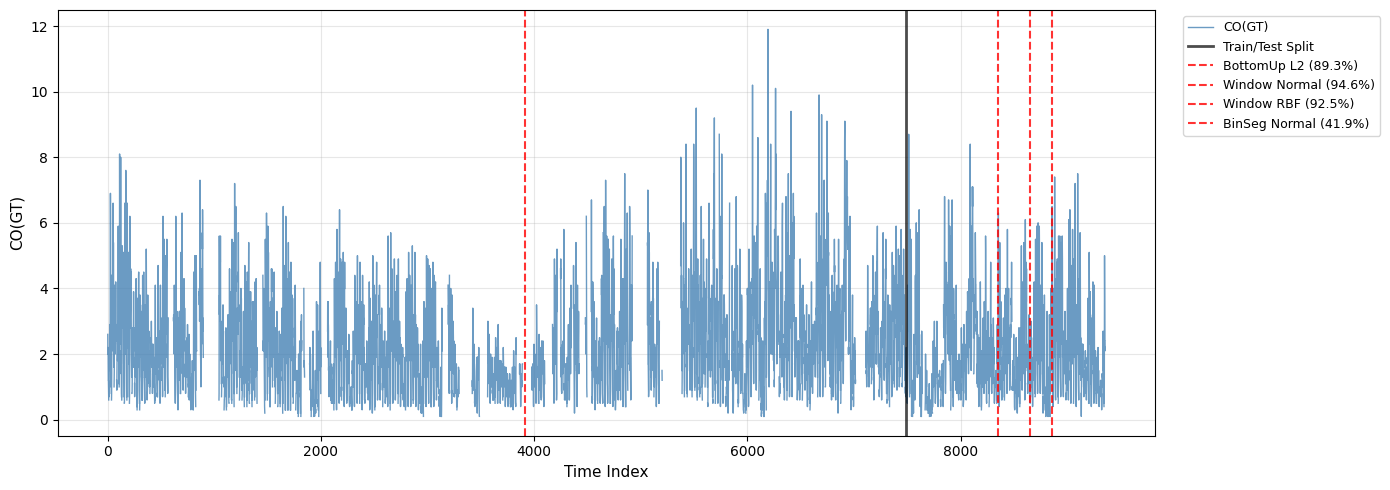


Appliances Energy:


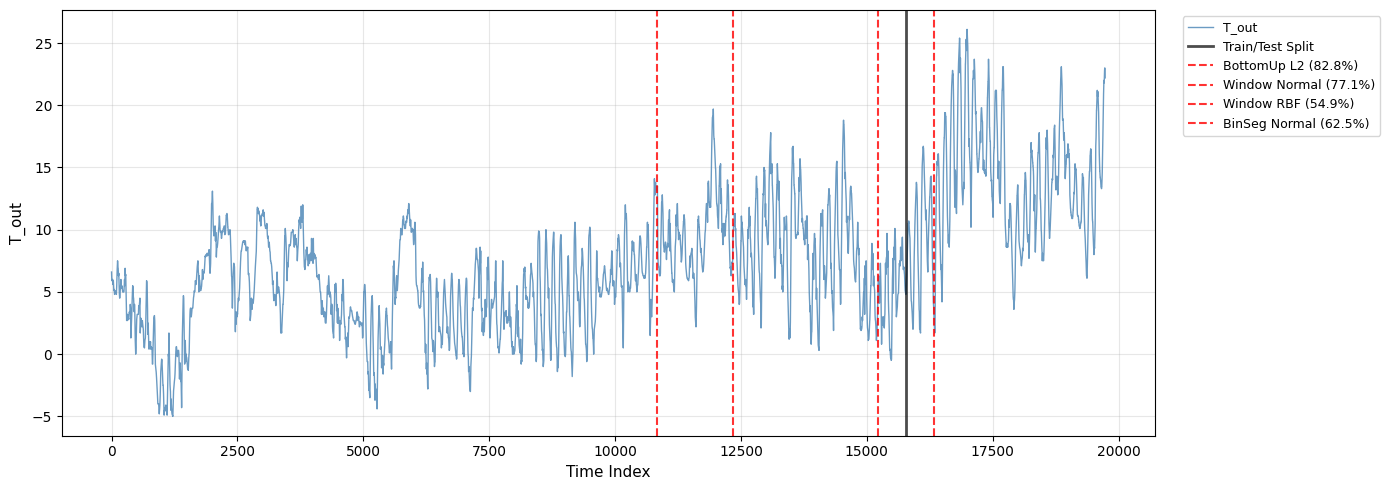


Beijing PM2.5:


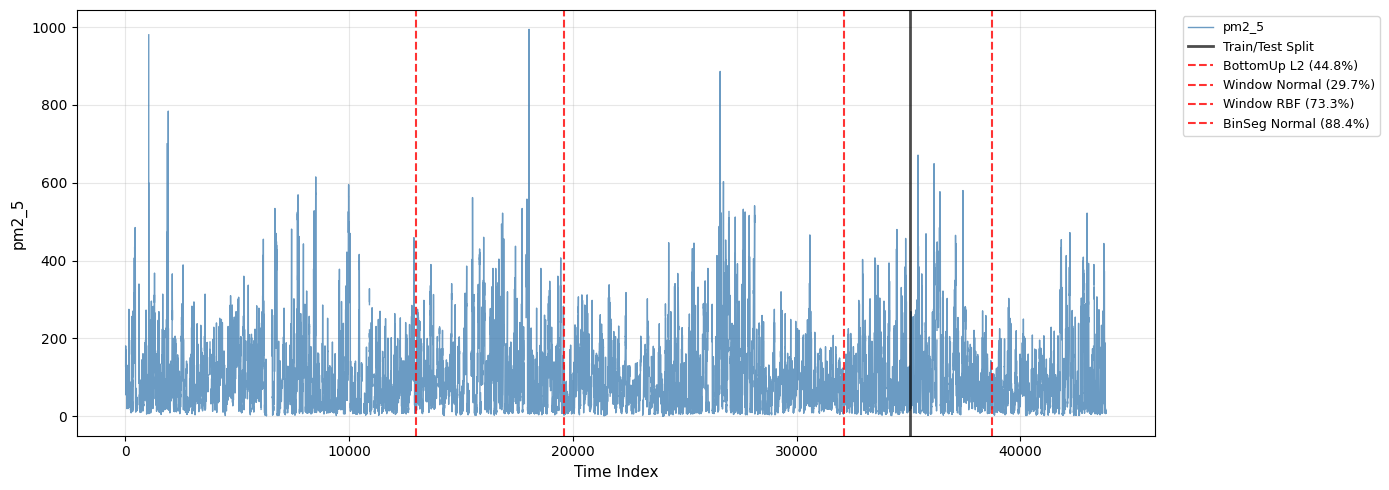


INMET São Paulo:


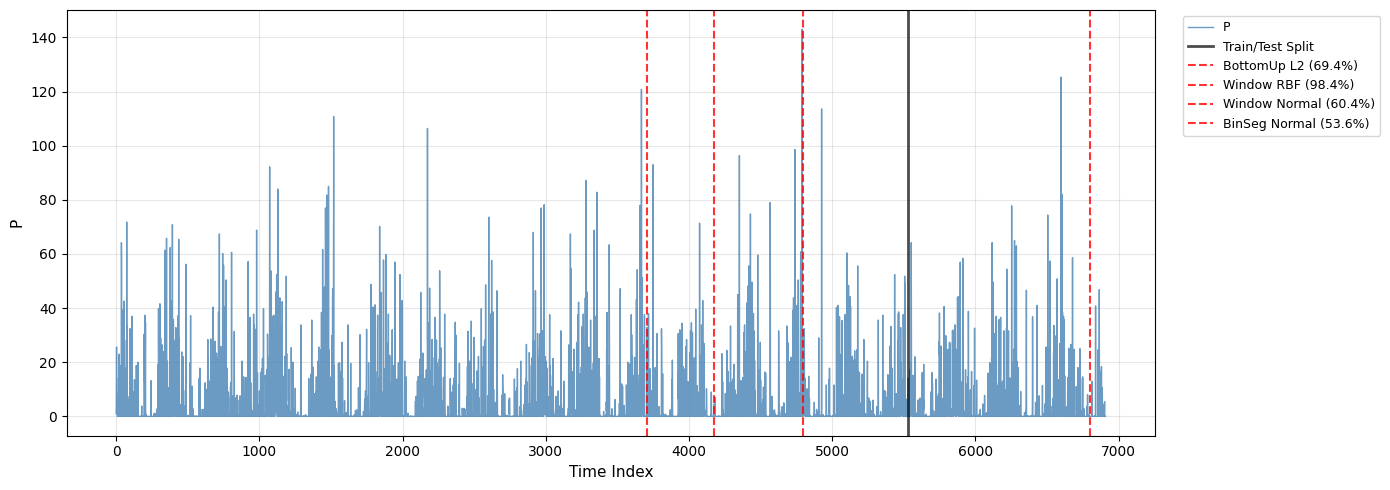


Metro Traffic:


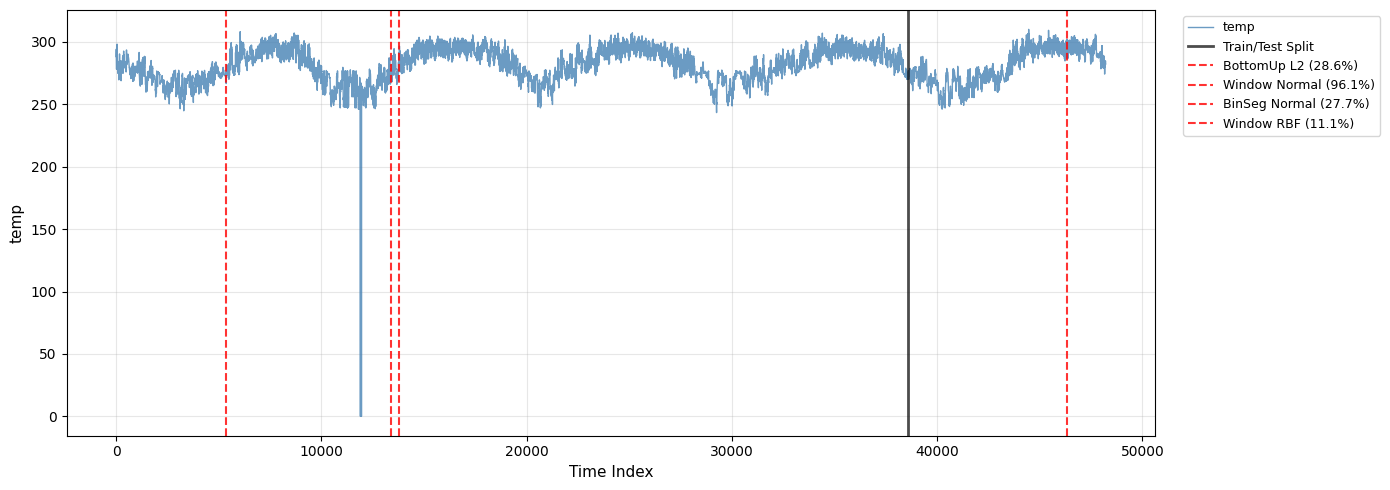


Weather:


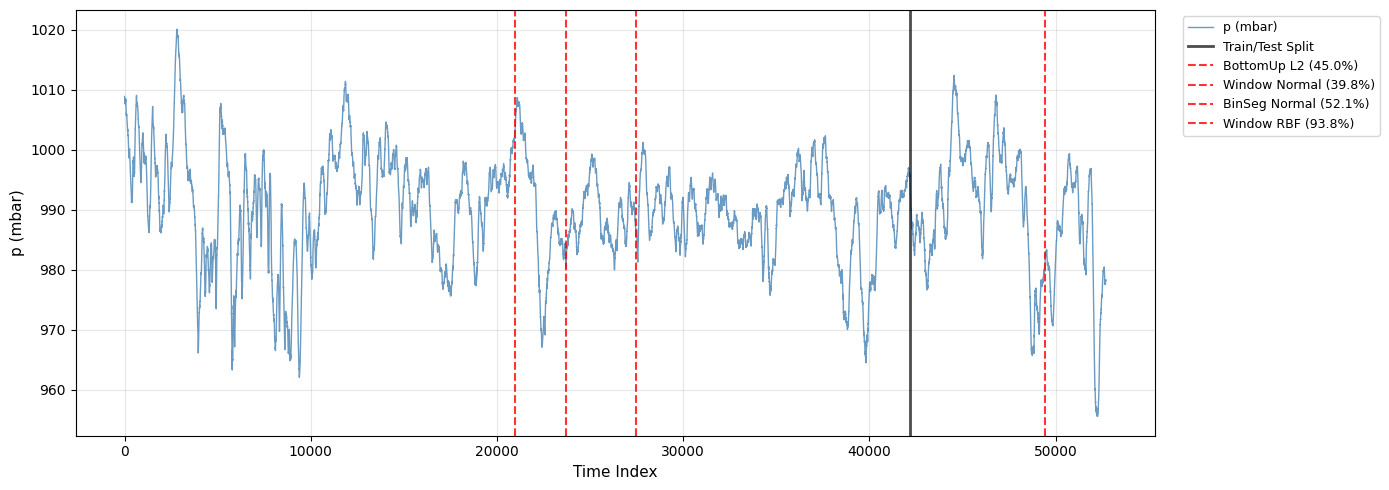

In [4]:
# Plot change points for each dataset (using LSTM metrics as reference)
print("="*60 + "\nCHANGE POINT DETECTION PLOTS\n" + "="*60)
for dataset_name in DATASETS_NAMES:
    print(f"\n{DATASETS_DISPLAY_NAMES[dataset_name]}:")
    plot_change_points(
        dataset_name,
        all_metrics["LSTM"][dataset_name],
        OUTPUT_FOLDER,
        n_approaches=5,
        filename=f"{dataset_name.lower()}_change_points.png"
    )

## 3. Results Tables (Per Forecaster)

In [5]:
print("="*60 + "\nLSTM RESULTS\n" + "="*60)

get_latex_tables(
    all_metrics["LSTM"], col_prefix=RMSE_COL, file_name="rmse_results",
    table_caption="RMSE results (mean $\\pm$ std)", table_label="tab:lstmRmse",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)
get_latex_tables(
    all_metrics["LSTM"], col_prefix=ET_TOTAL_COL, file_name="et_results",
    table_caption="Execution Time in minutes (mean $\\pm$ std)", table_label="tab:lstmEt",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)

LSTM RESULTS
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//LSTM/rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//LSTM/et_results.tex


In [6]:
print("="*60 + "\nTCN RESULTS\n" + "="*60)

get_latex_tables(
    all_metrics["TCN"], col_prefix=RMSE_COL, file_name="rmse_results",
    table_caption="RMSE results (mean $\\pm$ std)", table_label="tab:tcnRmse",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)
get_latex_tables(
    all_metrics["TCN"], col_prefix=ET_TOTAL_COL, file_name="et_results",
    table_caption="Execution Time in minutes (mean $\\pm$ std)", table_label="tab:tcnEt",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)

TCN RESULTS
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//TCN/rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//TCN/et_results.tex


In [7]:
# CPD cuts (same for both forecasters)
get_cpd_cuts_latex_table(all_metrics["LSTM"], OUTPUT_FOLDER, "cpd_cuts")

Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//cpd_cuts.tex


In [8]:
# LSTM Fixed Cut tables
get_fixed_cut_latex_tables(
    all_metrics["LSTM"], col_prefix=RMSE_COL, file_name="fixed_cut_rmse_results",
    table_caption="Fixed Cut Baseline RMSE results (mean $\\pm$ std)", table_label="tab:fixedCutRmse",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)
get_fixed_cut_latex_tables(
    all_metrics["LSTM"], col_prefix=ET_TOTAL_COL, file_name="fixed_cut_et_results",
    table_caption="Fixed Cut Baseline Execution Time in minutes (mean $\\pm$ std)", table_label="tab:fixedCutEt",
    output_path=f"{OUTPUT_FOLDER}/LSTM", forecaster_type="LSTM", higher_is_better=False
)

# TCN Fixed Cut tables
get_fixed_cut_latex_tables(
    all_metrics["TCN"], col_prefix=RMSE_COL, file_name="fixed_cut_rmse_results",
    table_caption="Fixed Cut Baseline RMSE results (mean $\\pm$ std)", table_label="tab:fixedCutRmse",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)
get_fixed_cut_latex_tables(
    all_metrics["TCN"], col_prefix=ET_TOTAL_COL, file_name="fixed_cut_et_results",
    table_caption="Fixed Cut Baseline Execution Time in minutes (mean $\\pm$ std)", table_label="tab:fixedCutEt",
    output_path=f"{OUTPUT_FOLDER}/TCN", forecaster_type="TCN", higher_is_better=False
)

Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//LSTM/fixed_cut_rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//LSTM/fixed_cut_et_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//TCN/fixed_cut_rmse_results.tex
Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//TCN/fixed_cut_et_results.tex


## 4. Statistical Tests (Per Forecaster)

In [9]:
for forecaster in FORECASTER_TYPES:
    print(f"\n{'='*60}\n{forecaster} Friedman Tests\n{'='*60}")
    for name, col in [("RMSE", f"{RMSE_COL}_mean"), ("ET", f"{ET_TOTAL_COL}_mean")]:
        print(f"\n{name}:")
        get_friedman_significance_overall(all_metrics[forecaster], col)


LSTM Friedman Tests

RMSE:
  Friedman Test: stat=15.4545, p=0.116348 (using 11 approaches)
  No significant difference.

ET:
  Friedman Test: stat=49.5152, p=0.000000 (using 11 approaches)
  Significant difference detected.

TCN Friedman Tests

RMSE:
  Friedman Test: stat=17.7879, p=0.058649 (using 11 approaches)
  No significant difference.

ET:
  Friedman Test: stat=52.0000, p=0.000000 (using 11 approaches)
  Significant difference detected.


## 5. Multi-Criteria Evaluation (Combined LSTM + TCN)

Ranking approaches across **both forecasters** considering RMSE and Execution Time trade-offs.

In [10]:
# Combine data from both forecasters
combined_dfs = []
for forecaster in FORECASTER_TYPES:
    df = all_comp_dfs[forecaster].copy()
    df['forecaster'] = forecaster
    combined_dfs.append(df)

combined_df = pd.concat(combined_dfs, ignore_index=True)
# Create unique dataset names for analysis (dataset_forecaster)
combined_df[DATASET_NAME_COL] = combined_df[DATASET_NAME_COL] + "_" + combined_df['forecaster']

print(f"Combined: {len(combined_df)} rows = {len(FORECASTER_TYPES)} forecasters x {len(DATASETS_NAMES)} datasets x methods")

Combined: 132 rows = 2 forecasters x 6 datasets x methods


### 5.1 Pareto Frontier Analysis

Running Pareto Analysis with: RMSE (minimize) + ET (minimize)

PARETO FRONT CONSISTENCY ANALYSIS
Optimizing: RMSE + Execution Time

Total datasets analyzed: 12
Total unique methods in any Pareto front: 11

Methods appearing in ALL Pareto fronts (12/12 = 100%):
  - Fixed Cut 90%

Methods appearing in majority of Pareto fronts (>= 50%):
  - BottomUp L2: 8/12 (66.7%)
  - Fixed Cut 50%: 6/12 (50.0%)
  - Window Normal: 7/12 (58.3%)
  - BinSeg Normal: 6/12 (50.0%)
  - Fixed Cut 10%: 6/12 (50.0%)
  - Fixed Cut 60%: 6/12 (50.0%)
  - Fixed Cut 80%: 6/12 (50.0%)


,Method,Pareto Count,Pareto Percentage,Datasets
2,Fixed Cut 90%,12,100.0,"UCI_AIR_QUALITY_LSTM, UCI_APPLIANCES_ENERGY_LS..."
0,BottomUp L2,8,66.7,"UCI_AIR_QUALITY_LSTM, UCI_APPLIANCES_ENERGY_LS..."
3,Window Normal,7,58.3,"UCI_AIR_QUALITY_LSTM, UCI_APPLIANCES_ENERGY_LS..."
1,Fixed Cut 50%,6,50.0,"UCI_AIR_QUALITY_LSTM, UCI_PRSA_BEIJING_LSTM, I..."
4,BinSeg Normal,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, UCI_PRSA_BEIJING_L..."
5,Fixed Cut 10%,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, INMET_SAOPAULO_SP_..."
6,Fixed Cut 60%,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, UCI_PRSA_BEIJING_L..."
7,Fixed Cut 80%,6,50.0,"UCI_APPLIANCES_ENERGY_LSTM, UCI_PRSA_BEIJING_L..."
9,Fixed Cut 40%,5,41.7,"UCI_PRSA_BEIJING_LSTM, INMET_SAOPAULO_SP_LSTM,..."
10,No CPD,4,33.3,"UCI_PRSA_BEIJING_LSTM, INMET_SAOPAULO_SP_LSTM,..."


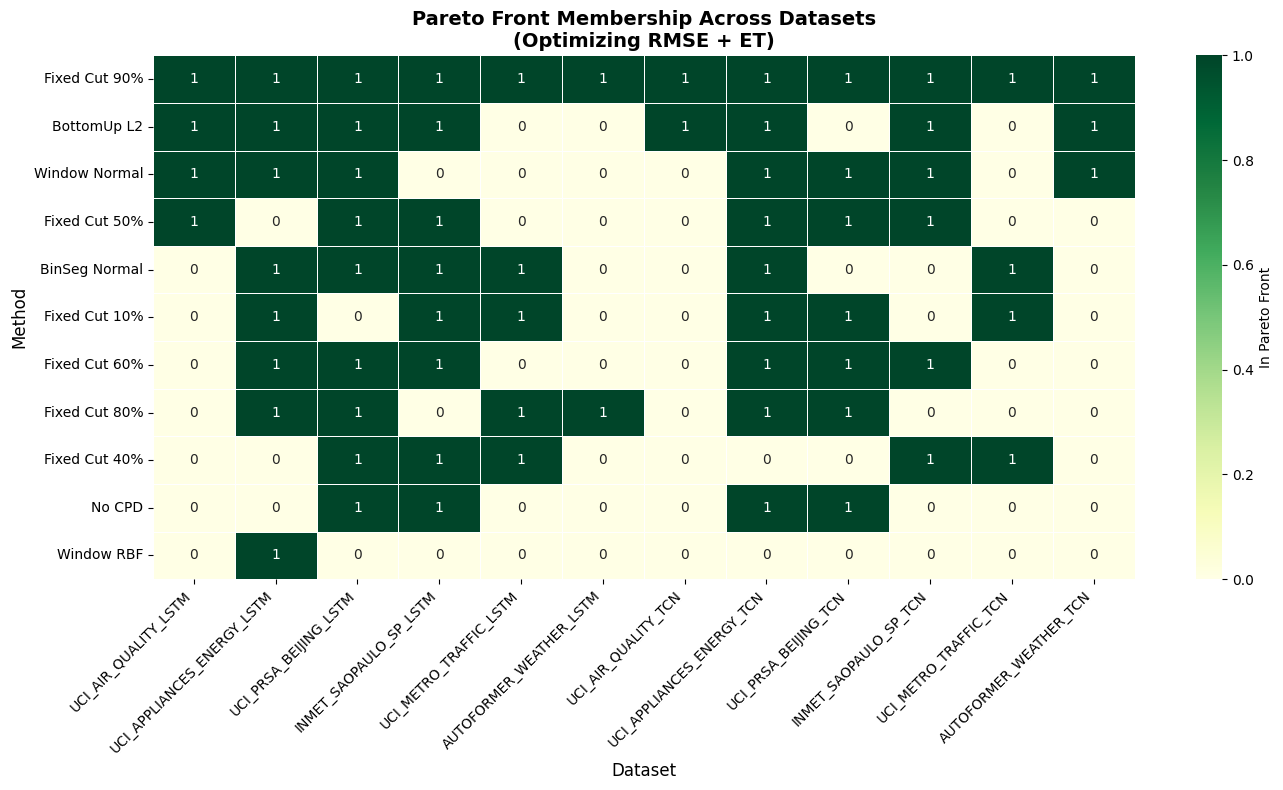

Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//pareto_combined.xlsx


In [11]:
pareto_summary, pareto_by_ds = analyze_pareto_consistency(combined_df, PRIMARY_METRIC, OUTPUT_FOLDER)
display_with_latex(pareto_summary, "Pareto Front Consistency (LSTM+TCN)", "tab:paretoCombined")
plot_pareto_heatmap(pareto_summary, pareto_by_ds, PRIMARY_METRIC, OUTPUT_FOLDER)
save_results_to_excel(pareto_summary, OUTPUT_FOLDER, "pareto_combined")

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


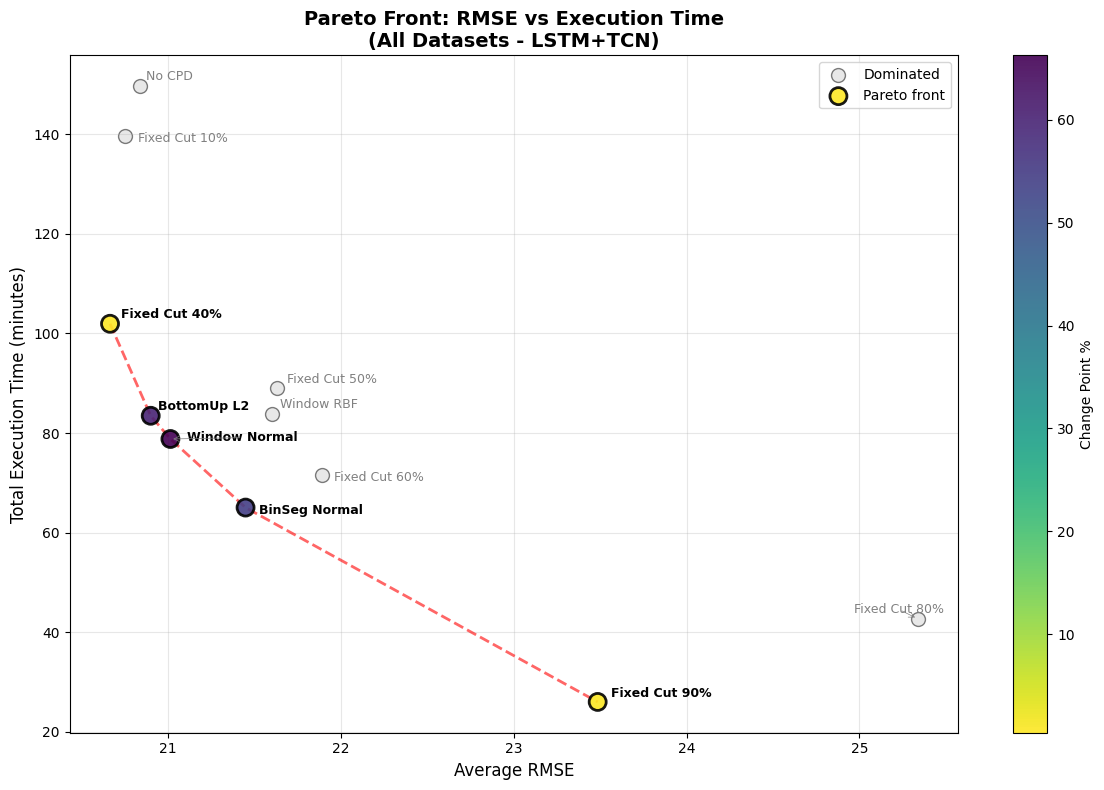


Pareto Optimal Approaches - All Datasets / LSTM+TCN (optimizing RMSE and ET):
Fixed Cut 40%                  | RMSE: 20.6634 | ET:   101.95 min
BottomUp L2                    | RMSE: 20.8989 | ET:    83.48 min
Window Normal                  | RMSE: 21.0129 | ET:    78.81 min
BinSeg Normal                  | RMSE: 21.4477 | ET:    65.05 min
Fixed Cut 90%                  | RMSE: 23.4854 | ET:    26.03 min


,change_point_approach,Avg_RMSE,ET_Total,change_point_perc,is_pareto
3,Fixed Cut 40%,20.663442,101.946717,0.400000,True
1,BottomUp L2,20.898908,83.475825,59.964233,True
9,Window Normal,21.012883,78.814358,66.283283,True
0,BinSeg Normal,21.447733,65.047100,54.369483,True
7,Fixed Cut 90%,23.485425,26.030100,0.900000,True


In [12]:
# Aggregate combined data to get mean values across all datasets/forecasters
combined_agg = combined_df.groupby(CHANGE_POINT_APPROACH_COL).agg({
    f"{PRIMARY_METRIC}_mean": "mean",
    f"{ET_TOTAL_COL}_mean": "mean",
    f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": "mean"
}).reset_index()

# Rename columns to match plot_pareto_front expectations
combined_agg = combined_agg.rename(columns={
    f"{PRIMARY_METRIC}_mean": PRIMARY_METRIC,
    f"{ET_TOTAL_COL}_mean": ET_TOTAL_COL,
    f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": CHANGE_POINT_PERC_COL
})

# Plot the combined Pareto front
plot_pareto_front(
    combined_agg, 
    OUTPUT_FOLDER, 
    PRIMARY_METRIC,
    filename="pareto_front_combined.png",
    dataset_name="All Datasets",
    forecaster_type="LSTM+TCN"
)

### 5.2 Weighted Scalarization

In [13]:
ws_df = compute_weighted_scalarization_sensitivity(combined_df, PRIMARY_METRIC)
display_with_latex(ws_df, "Weighted Scalarization (LSTM+TCN)", "tab:weightedCombined", precision=0)
save_results_to_excel(ws_df, OUTPUT_FOLDER, "weighted_scalarization_combined")

,change_point_approach,α=0.1,α=0.3,α=0.5,α=0.7,α=0.9,avg_rank
0,BinSeg Normal,3.0,2.0,1.0,4.0,6.0,3.2
9,Window Normal,5.0,3.0,2.0,2.0,4.0,3.2
1,BottomUp L2,6.0,5.0,3.0,1.0,2.0,3.4
7,Fixed Cut 90%,1.0,1.0,4.0,10.0,10.0,5.2
3,Fixed Cut 40%,9.0,9.0,5.0,3.0,1.0,5.4
5,Fixed Cut 60%,4.0,4.0,6.0,7.0,9.0,6.0
10,Window RBF,7.0,6.0,7.0,5.0,7.0,6.4
2,Fixed Cut 10%,10.0,10.0,9.0,6.0,3.0,7.6
4,Fixed Cut 50%,8.0,8.0,8.0,8.0,8.0,8.0
6,Fixed Cut 80%,2.0,7.0,11.0,11.0,11.0,8.4


Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//weighted_scalarization_combined.xlsx


### 5.3 Dominance Ranking

In [14]:
dom_df = compute_dominance_ranking(combined_df, PRIMARY_METRIC)
display_with_latex(dom_df, "Dominance Ranking (LSTM+TCN)", "tab:dominanceCombined")
save_results_to_excel(dom_df, OUTPUT_FOLDER, "dominance_ranking_combined")

,change_point_approach,Avg_RMSE_mean,ET_Total_mean,dominated_count,rank
3,Fixed Cut 40%,20.663442,101.946717,0,1.0
1,BottomUp L2,20.898908,83.475825,0,1.0
9,Window Normal,21.012883,78.814358,0,1.0
0,BinSeg Normal,21.447733,65.047100,0,1.0
7,Fixed Cut 90%,23.485425,26.030100,0,1.0
2,Fixed Cut 10%,20.751517,139.657800,1,6.0
5,Fixed Cut 60%,21.890500,71.632908,1,6.0
6,Fixed Cut 80%,25.336500,42.734250,1,6.0
8,No CPD,20.839475,149.651967,2,9.0
10,Window RBF,21.598858,83.807558,3,10.0


Saved to /Users/zamith/Doutorado/OptimizingForecastingCPD/outputs/paper_v3/rolling//dominance_ranking_combined.xlsx


## 6. Visualizations


LSTM:


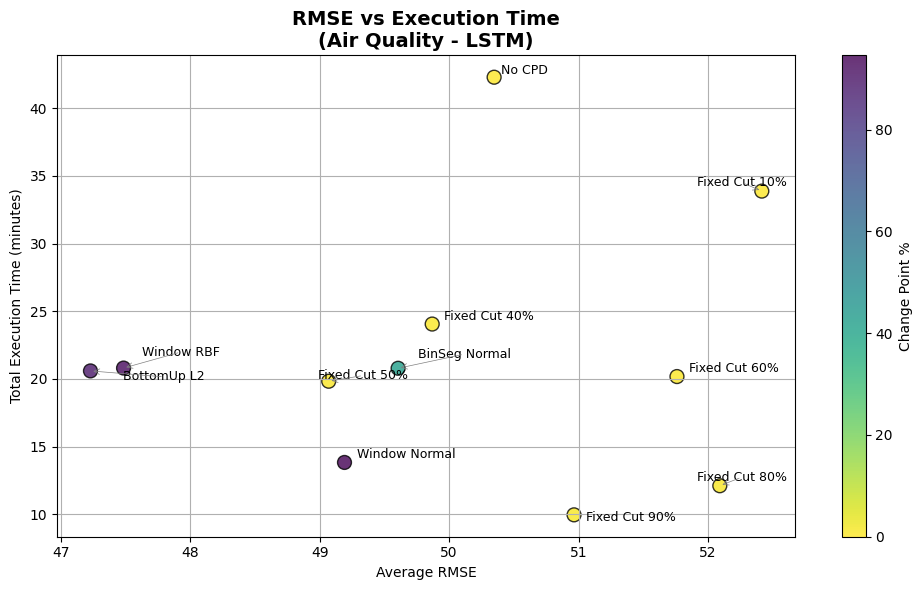

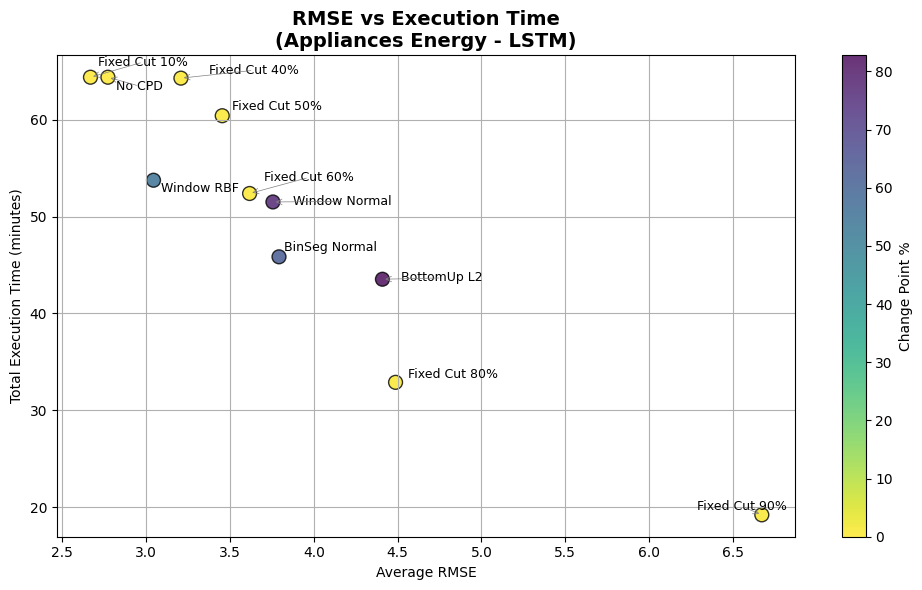

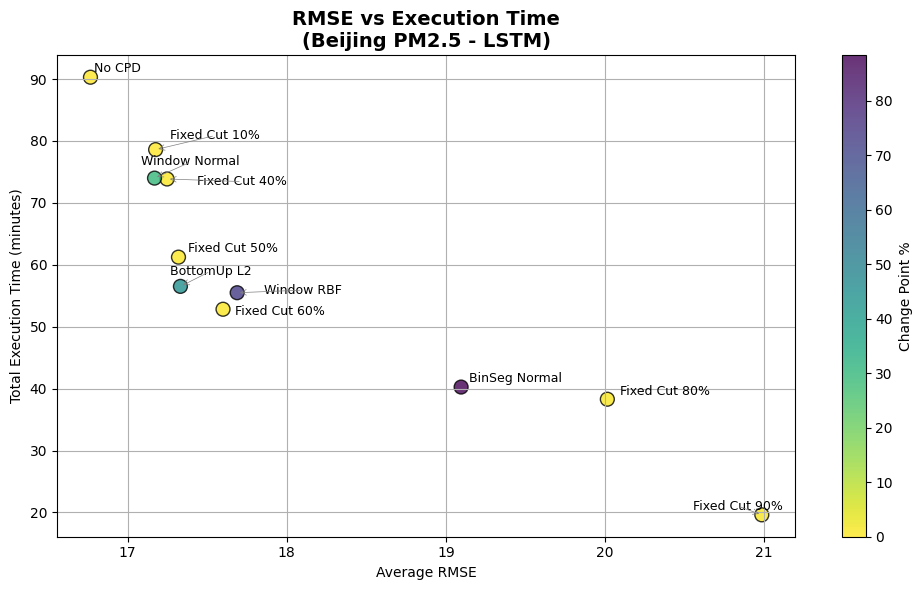

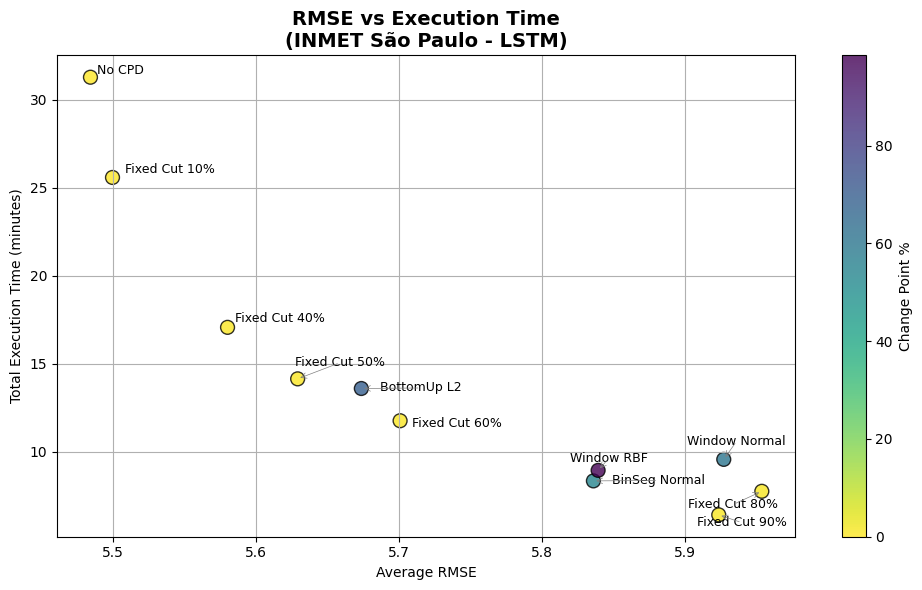

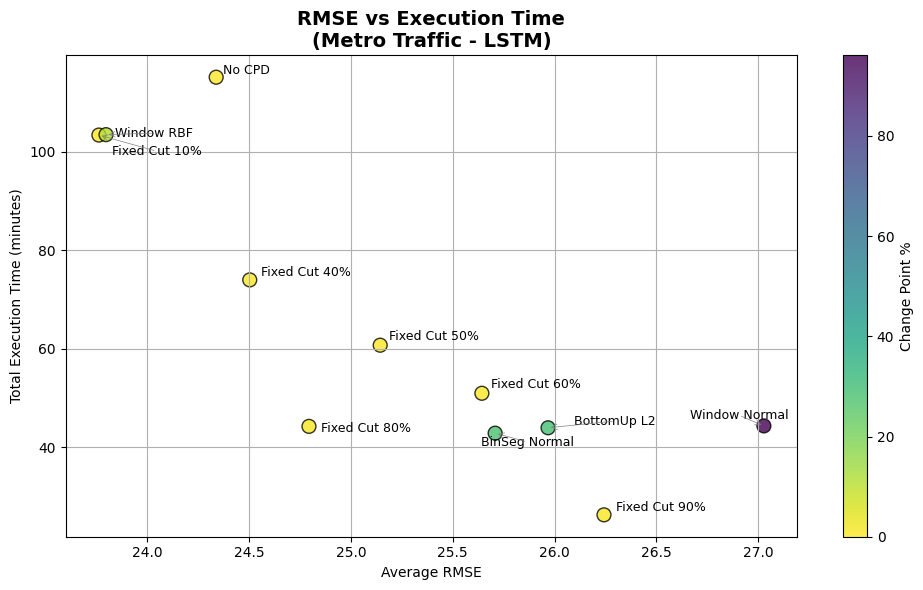

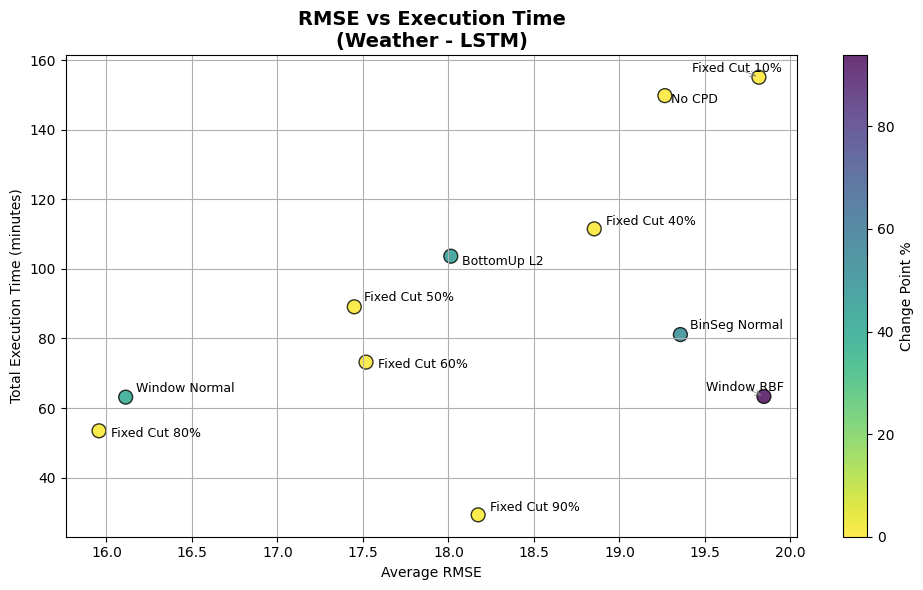


TCN:


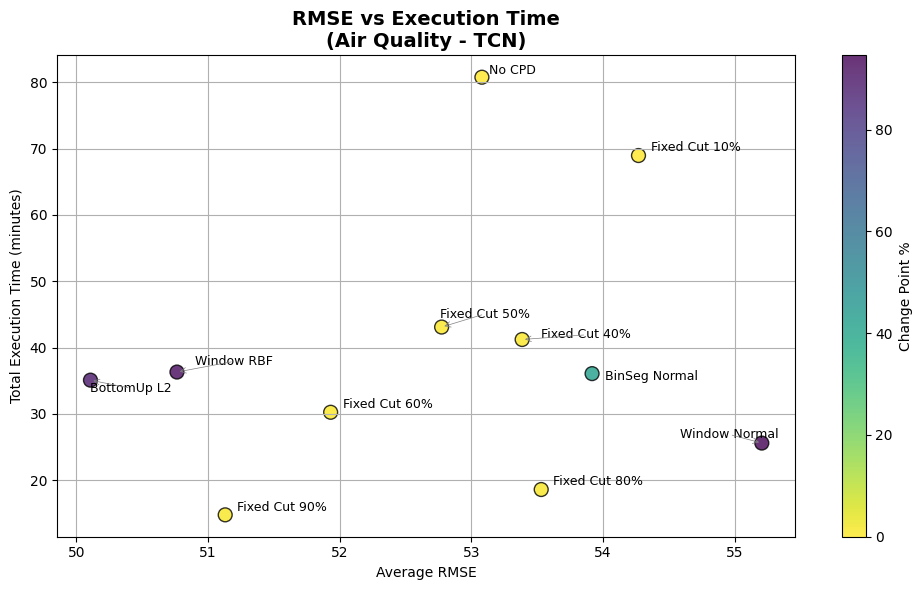

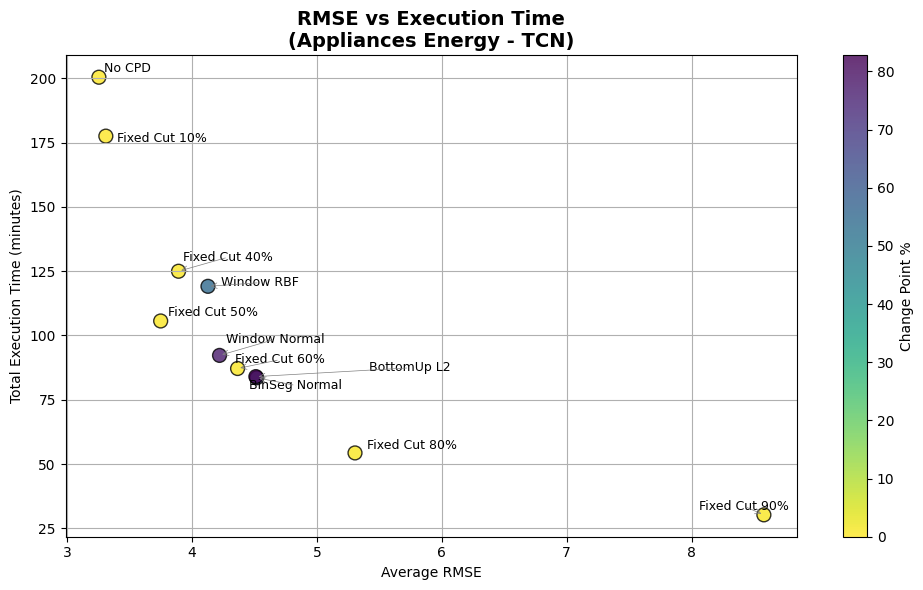

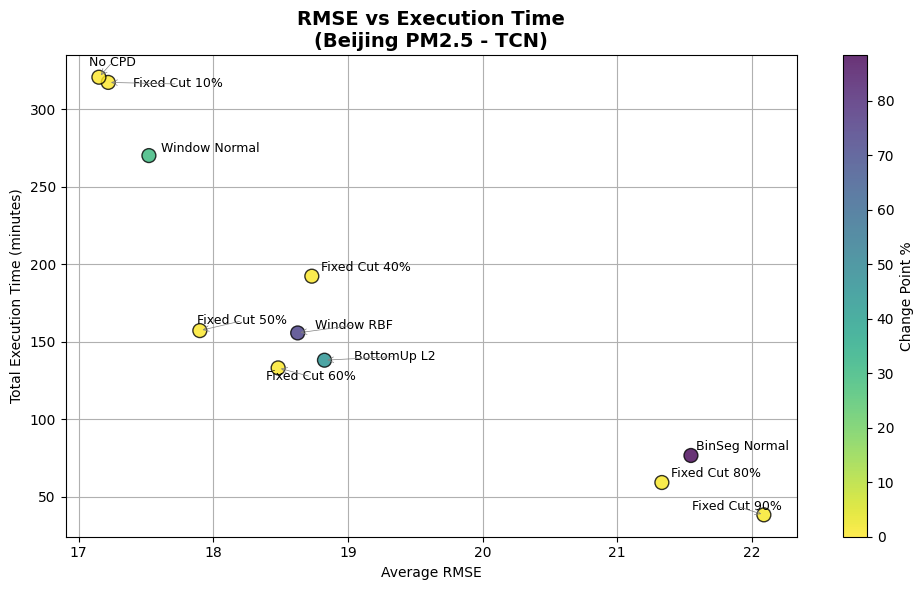

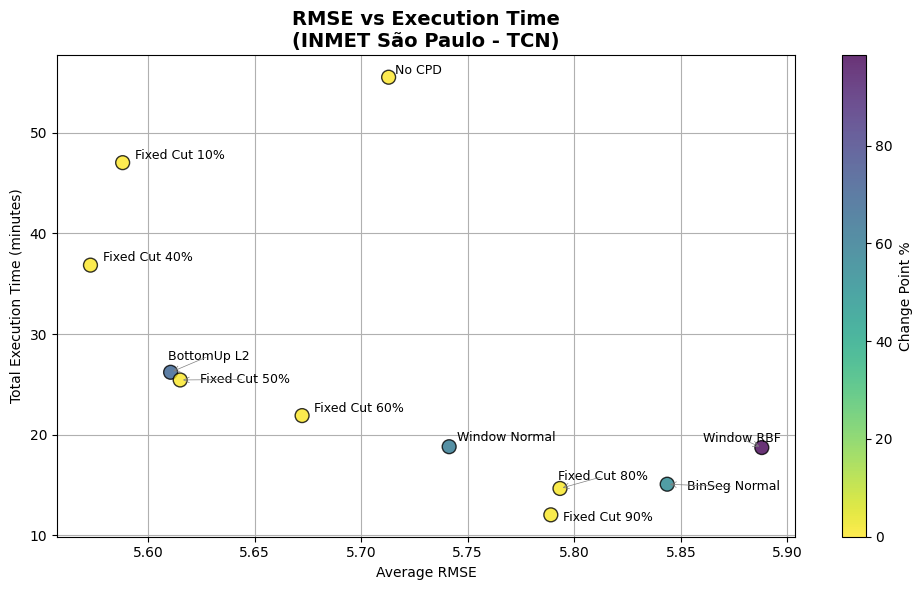

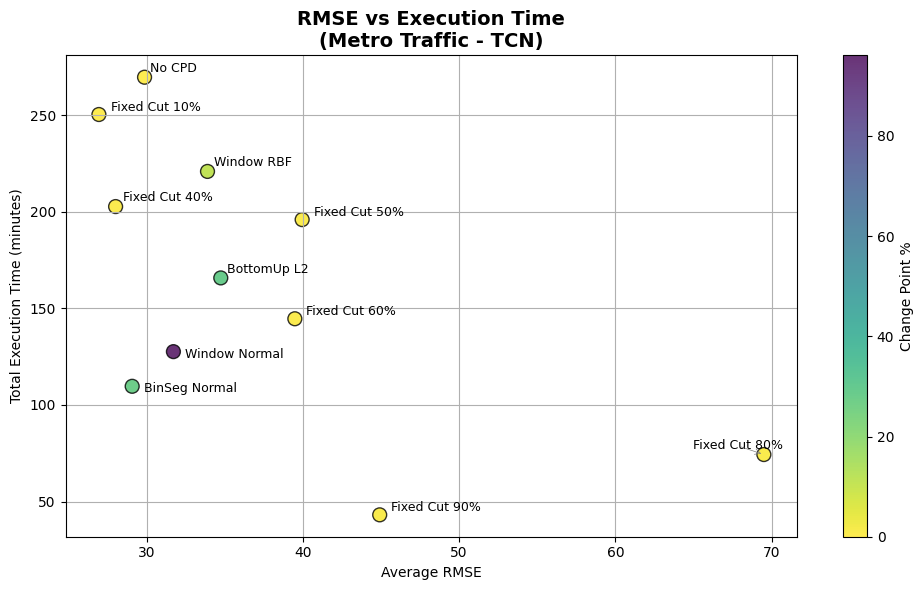

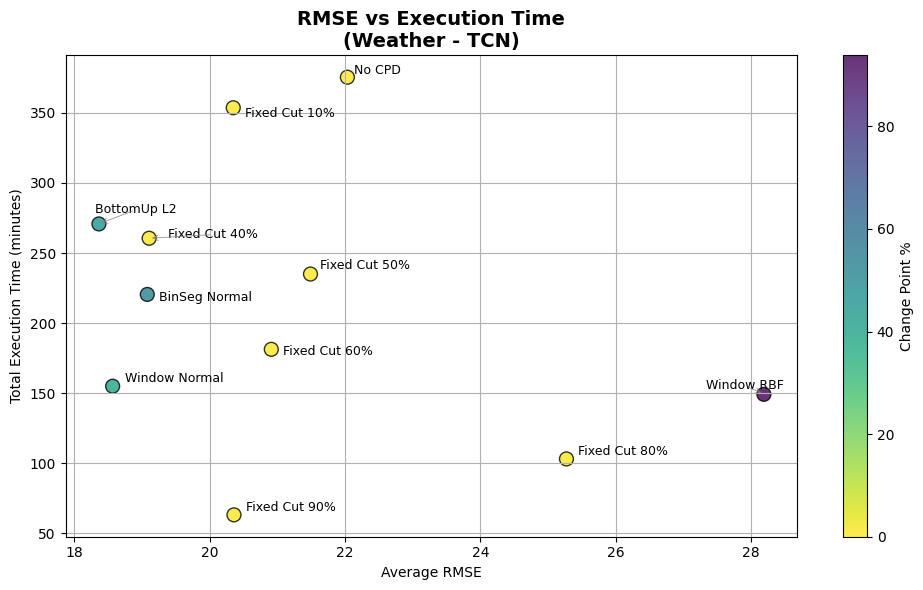

In [15]:
# Scatter plots per forecaster
for forecaster in FORECASTER_TYPES:
    print(f"\n{forecaster}:")
    for ds in DATASETS_NAMES:
        df = all_comp_dfs[forecaster][all_comp_dfs[forecaster][DATASET_NAME_COL] == ds].rename(columns={
            f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": CHANGE_POINT_PERC_COL,
            f"{PRIMARY_METRIC}_mean": PRIMARY_METRIC,
            f"{ET_TOTAL_COL}_mean": ET_TOTAL_COL,
        })
        plot_scatter_plot(df, f"{OUTPUT_FOLDER}/{forecaster}", PRIMARY_METRIC, 
                          filename=f"{ds}_scatter.png", dataset_name=ds, forecaster_type=forecaster)


LSTM:


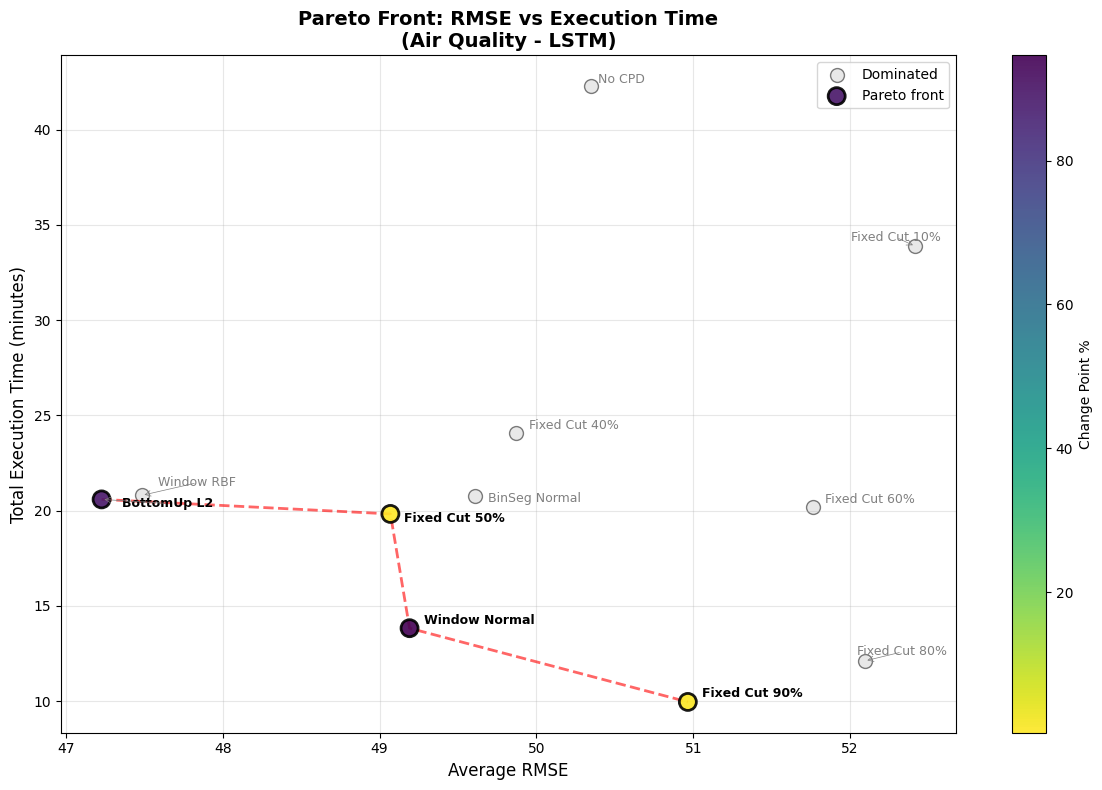


Pareto Optimal Approaches - Air Quality / LSTM (optimizing RMSE and ET):
BottomUp L2                    | RMSE: 47.2275 | ET:    20.59 min
Fixed Cut 50%                  | RMSE: 49.0689 | ET:    19.83 min
Window Normal                  | RMSE: 49.1910 | ET:    13.83 min
Fixed Cut 90%                  | RMSE: 50.9653 | ET:     9.96 min


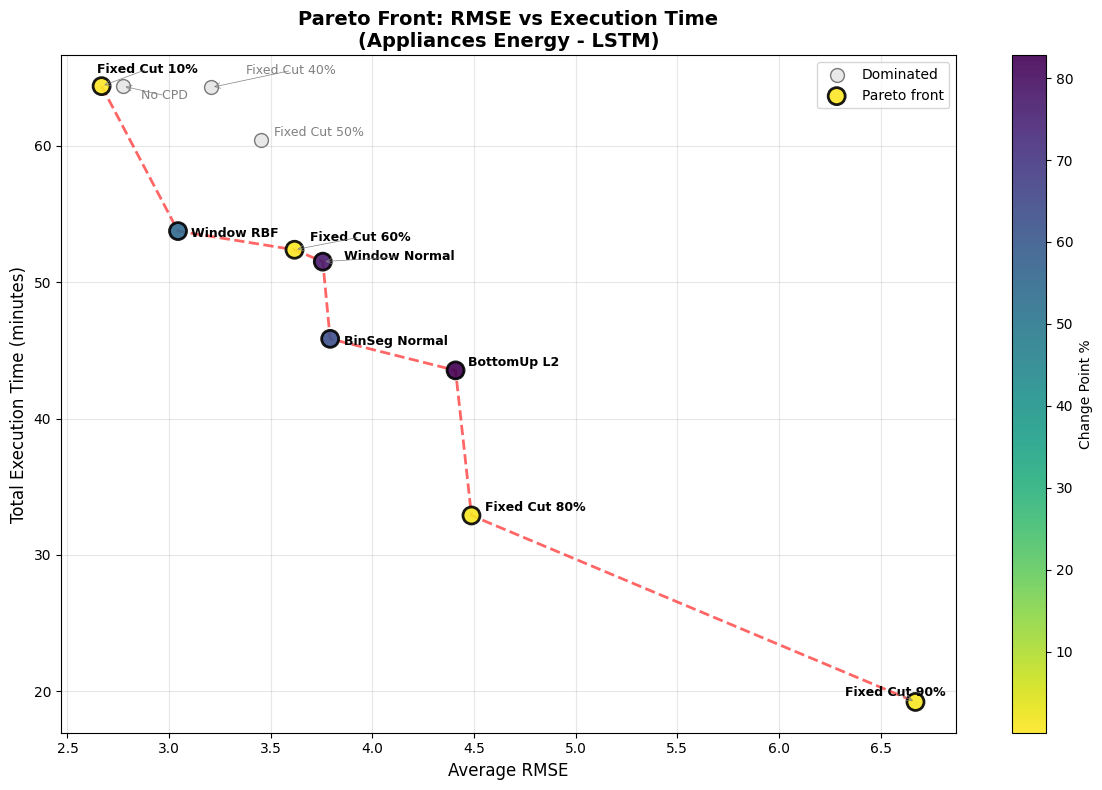


Pareto Optimal Approaches - Appliances Energy / LSTM (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 2.6679 | ET:    64.37 min
Window RBF                     | RMSE: 3.0439 | ET:    53.75 min
Fixed Cut 60%                  | RMSE: 3.6170 | ET:    52.38 min
Window Normal                  | RMSE: 3.7561 | ET:    51.50 min
BinSeg Normal                  | RMSE: 3.7924 | ET:    45.84 min
BottomUp L2                    | RMSE: 4.4093 | ET:    43.53 min
Fixed Cut 80%                  | RMSE: 4.4876 | ET:    32.89 min
Fixed Cut 90%                  | RMSE: 6.6721 | ET:    19.22 min


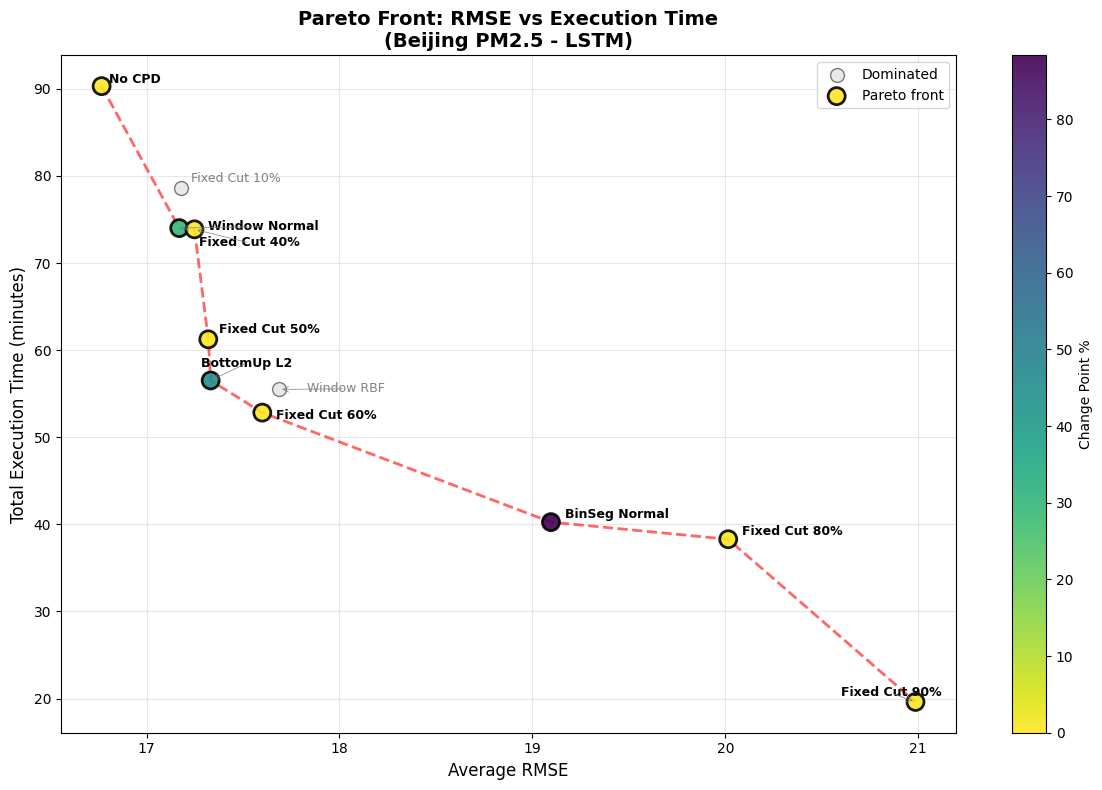


Pareto Optimal Approaches - Beijing PM2.5 / LSTM (optimizing RMSE and ET):
No CPD                         | RMSE: 16.7669 | ET:    90.30 min
Window Normal                  | RMSE: 17.1694 | ET:    74.01 min
Fixed Cut 40%                  | RMSE: 17.2482 | ET:    73.87 min
Fixed Cut 50%                  | RMSE: 17.3200 | ET:    61.24 min
BottomUp L2                    | RMSE: 17.3322 | ET:    56.52 min
Fixed Cut 60%                  | RMSE: 17.5999 | ET:    52.83 min
BinSeg Normal                  | RMSE: 19.0961 | ET:    40.26 min
Fixed Cut 80%                  | RMSE: 20.0150 | ET:    38.29 min
Fixed Cut 90%                  | RMSE: 20.9857 | ET:    19.62 min


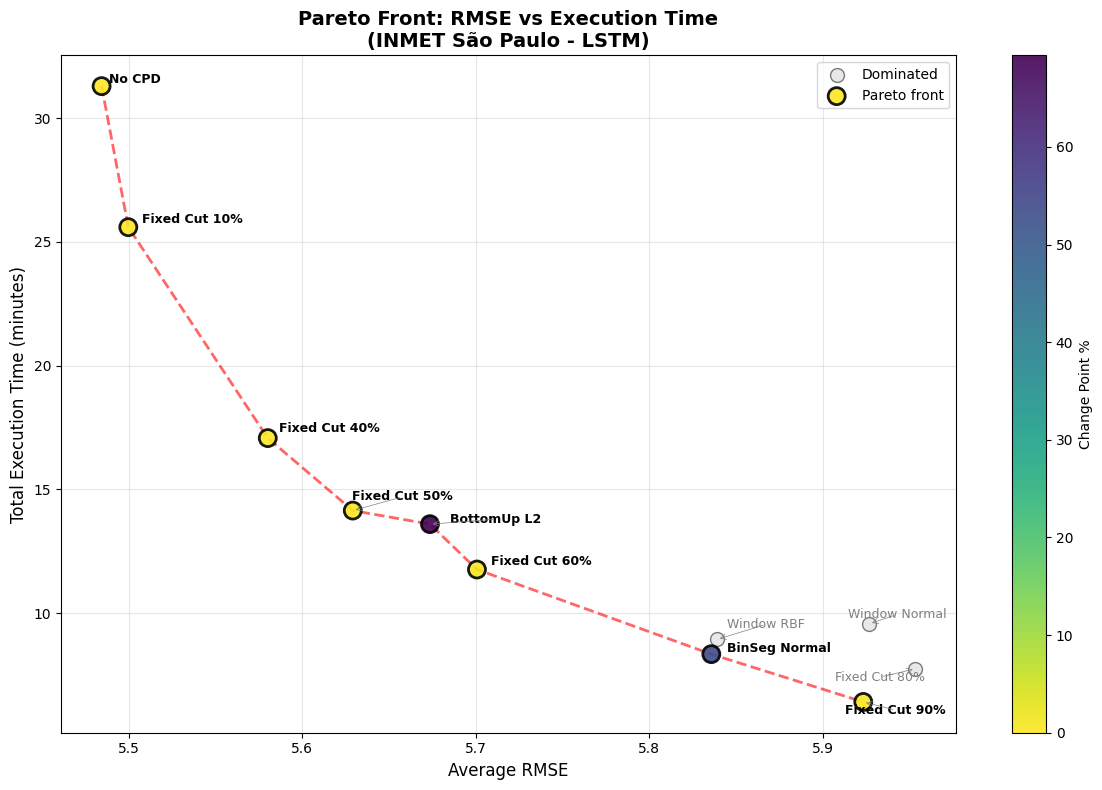


Pareto Optimal Approaches - INMET São Paulo / LSTM (optimizing RMSE and ET):
No CPD                         | RMSE: 5.4844 | ET:    31.30 min
Fixed Cut 10%                  | RMSE: 5.4998 | ET:    25.60 min
Fixed Cut 40%                  | RMSE: 5.5802 | ET:    17.07 min
Fixed Cut 50%                  | RMSE: 5.6292 | ET:    14.14 min
BottomUp L2                    | RMSE: 5.6737 | ET:    13.60 min
Fixed Cut 60%                  | RMSE: 5.7008 | ET:    11.76 min
BinSeg Normal                  | RMSE: 5.8359 | ET:     8.34 min
Fixed Cut 90%                  | RMSE: 5.9235 | ET:     6.41 min


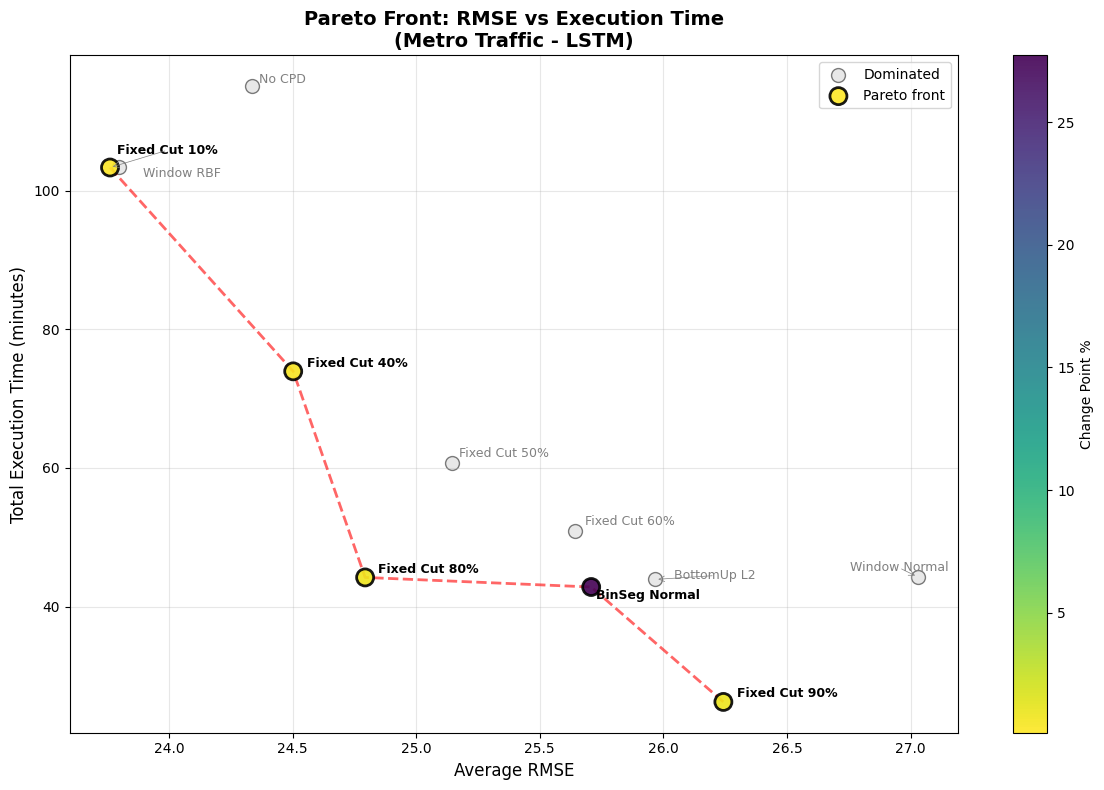


Pareto Optimal Approaches - Metro Traffic / LSTM (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 23.7613 | ET:   103.38 min
Fixed Cut 40%                  | RMSE: 24.5024 | ET:    73.95 min
Fixed Cut 80%                  | RMSE: 24.7934 | ET:    44.20 min
BinSeg Normal                  | RMSE: 25.7080 | ET:    42.82 min
Fixed Cut 90%                  | RMSE: 26.2428 | ET:    26.23 min


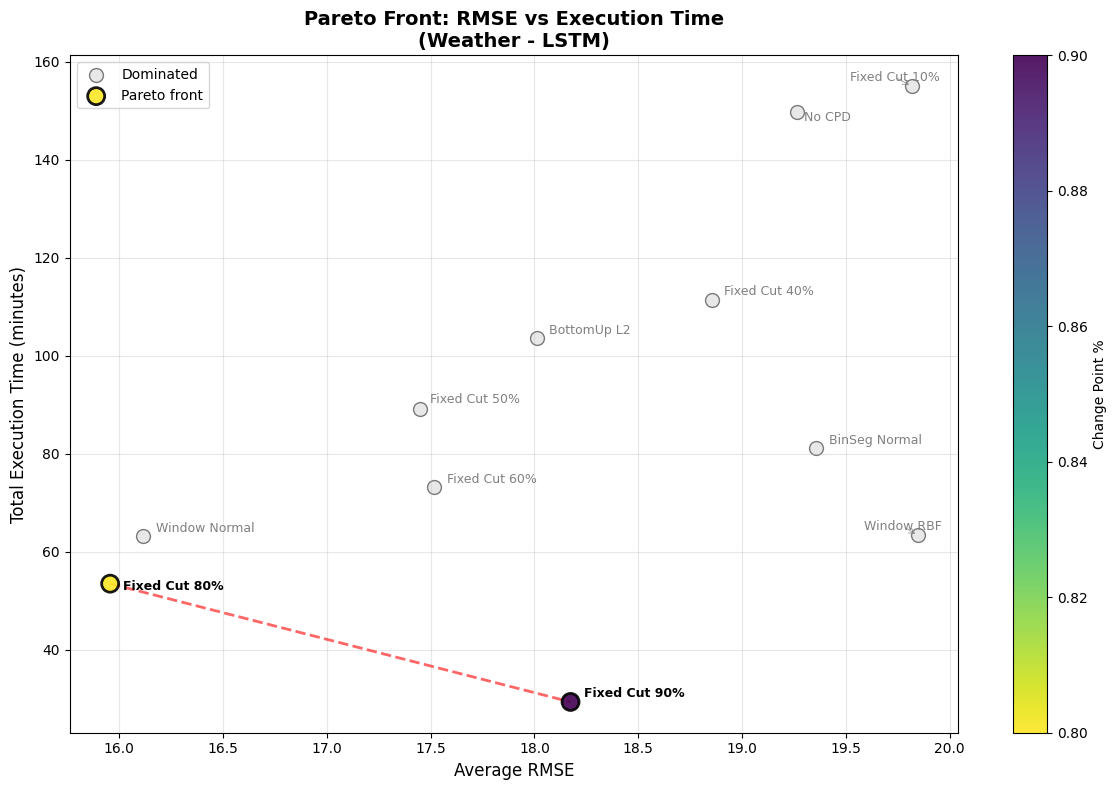


Pareto Optimal Approaches - Weather / LSTM (optimizing RMSE and ET):
Fixed Cut 80%                  | RMSE: 15.9568 | ET:    53.47 min
Fixed Cut 90%                  | RMSE: 18.1738 | ET:    29.32 min

TCN:


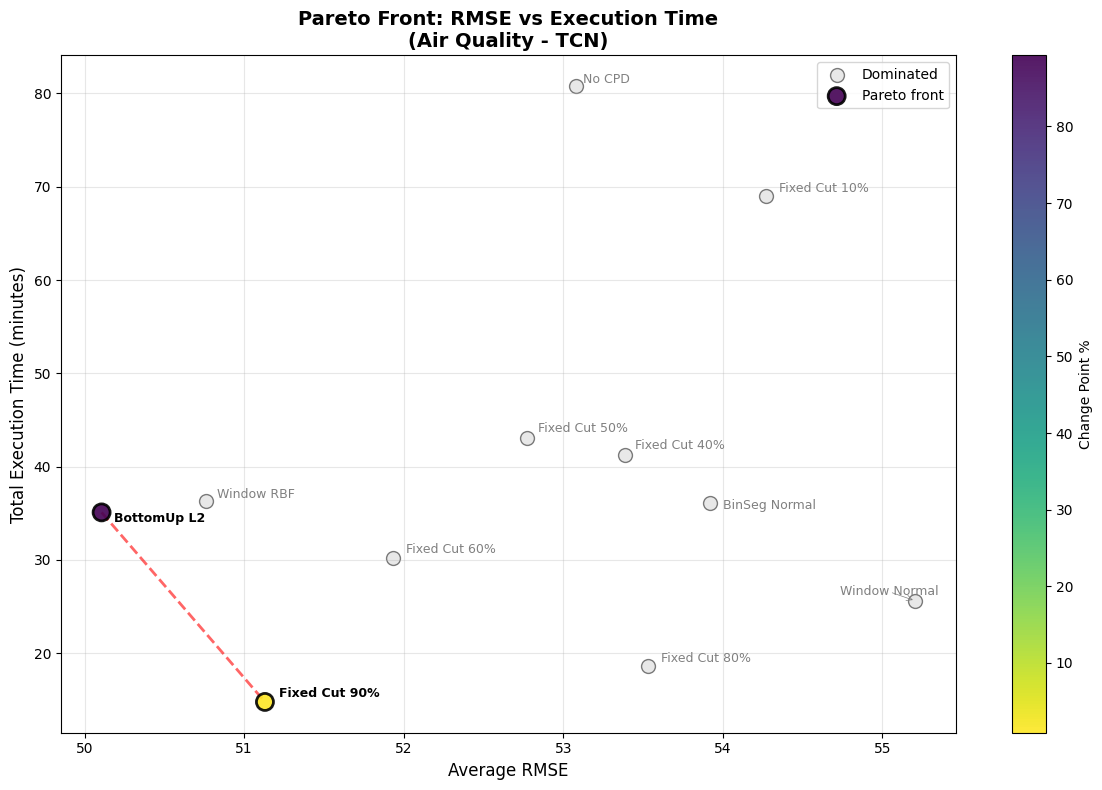


Pareto Optimal Approaches - Air Quality / TCN (optimizing RMSE and ET):
BottomUp L2                    | RMSE: 50.1070 | ET:    35.09 min
Fixed Cut 90%                  | RMSE: 51.1306 | ET:    14.77 min


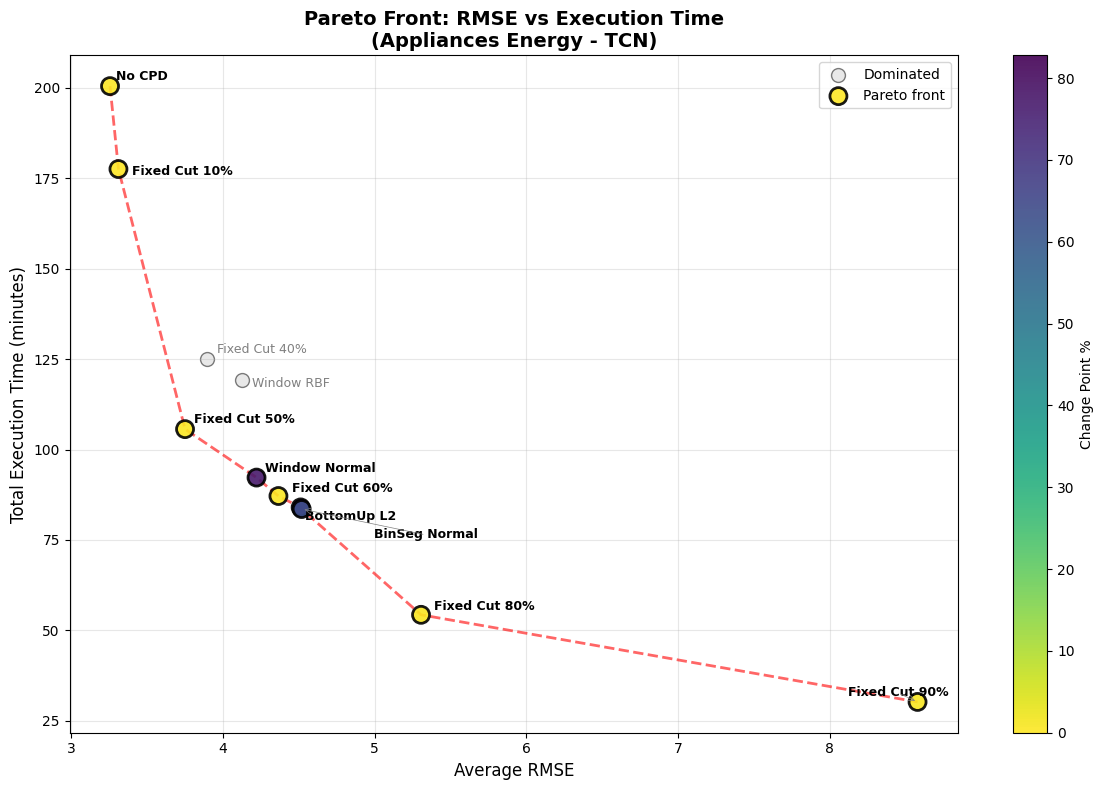


Pareto Optimal Approaches - Appliances Energy / TCN (optimizing RMSE and ET):
No CPD                         | RMSE: 3.2550 | ET:   200.43 min
Fixed Cut 10%                  | RMSE: 3.3105 | ET:   177.51 min
Fixed Cut 50%                  | RMSE: 3.7495 | ET:   105.63 min
Window Normal                  | RMSE: 4.2207 | ET:    92.25 min
Fixed Cut 60%                  | RMSE: 4.3652 | ET:    87.15 min
BottomUp L2                    | RMSE: 4.5115 | ET:    84.00 min
BinSeg Normal                  | RMSE: 4.5183 | ET:    83.55 min
Fixed Cut 80%                  | RMSE: 5.3051 | ET:    54.32 min
Fixed Cut 90%                  | RMSE: 8.5781 | ET:    30.25 min


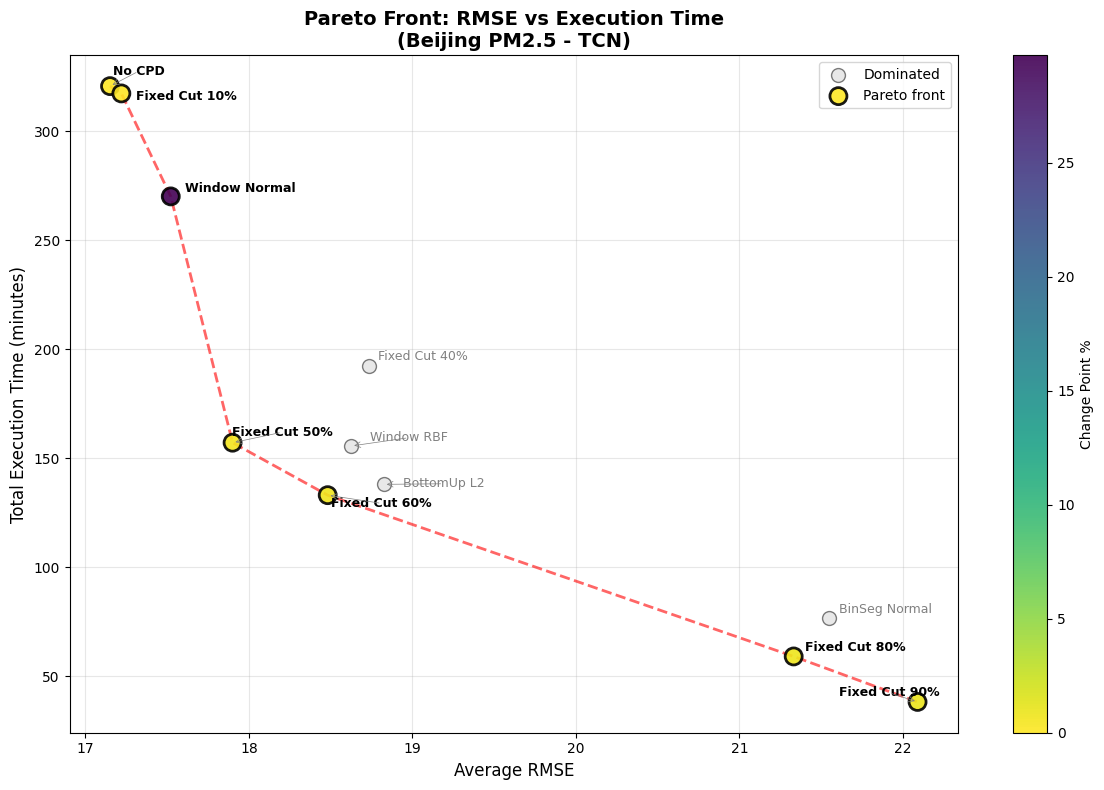


Pareto Optimal Approaches - Beijing PM2.5 / TCN (optimizing RMSE and ET):
No CPD                         | RMSE: 17.1509 | ET:   320.82 min
Fixed Cut 10%                  | RMSE: 17.2202 | ET:   317.47 min
Window Normal                  | RMSE: 17.5223 | ET:   270.22 min
Fixed Cut 50%                  | RMSE: 17.9004 | ET:   157.21 min
Fixed Cut 60%                  | RMSE: 18.4820 | ET:   133.13 min
Fixed Cut 80%                  | RMSE: 21.3317 | ET:    59.13 min
Fixed Cut 90%                  | RMSE: 22.0892 | ET:    38.26 min


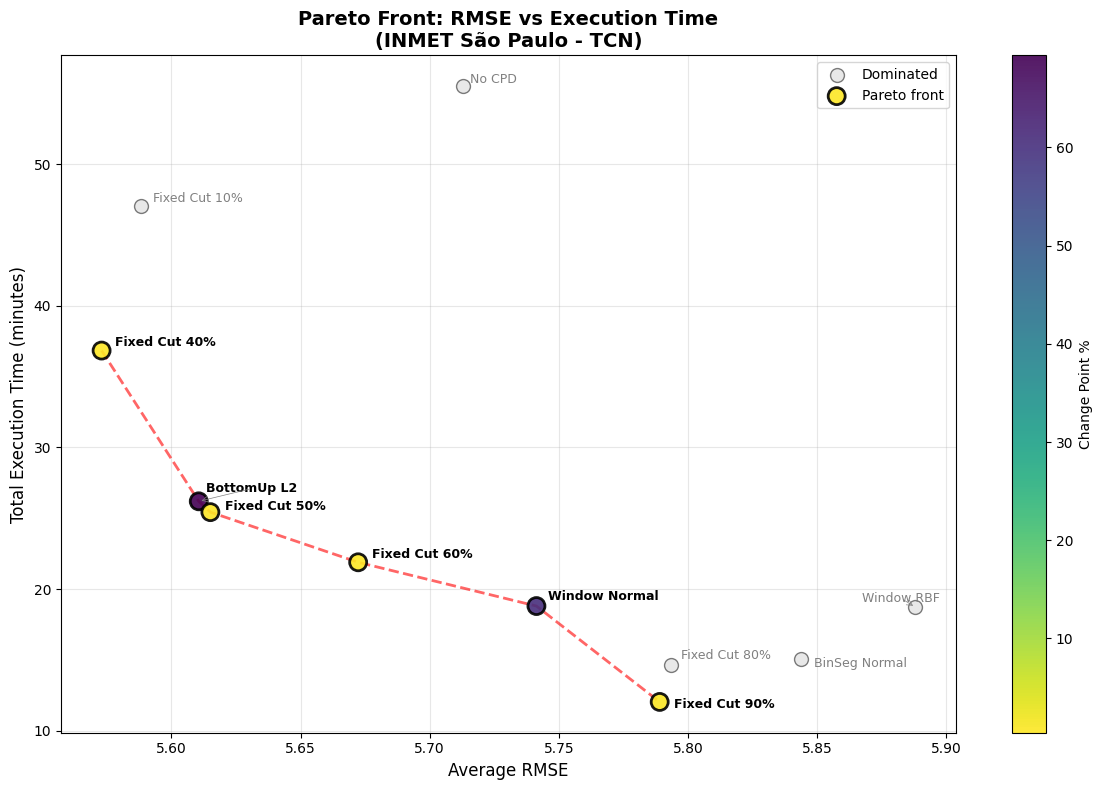


Pareto Optimal Approaches - INMET São Paulo / TCN (optimizing RMSE and ET):
Fixed Cut 40%                  | RMSE: 5.5730 | ET:    36.85 min
BottomUp L2                    | RMSE: 5.6106 | ET:    26.20 min
Fixed Cut 50%                  | RMSE: 5.6151 | ET:    25.43 min
Fixed Cut 60%                  | RMSE: 5.6723 | ET:    21.89 min
Window Normal                  | RMSE: 5.7413 | ET:    18.80 min
Fixed Cut 90%                  | RMSE: 5.7890 | ET:    12.03 min


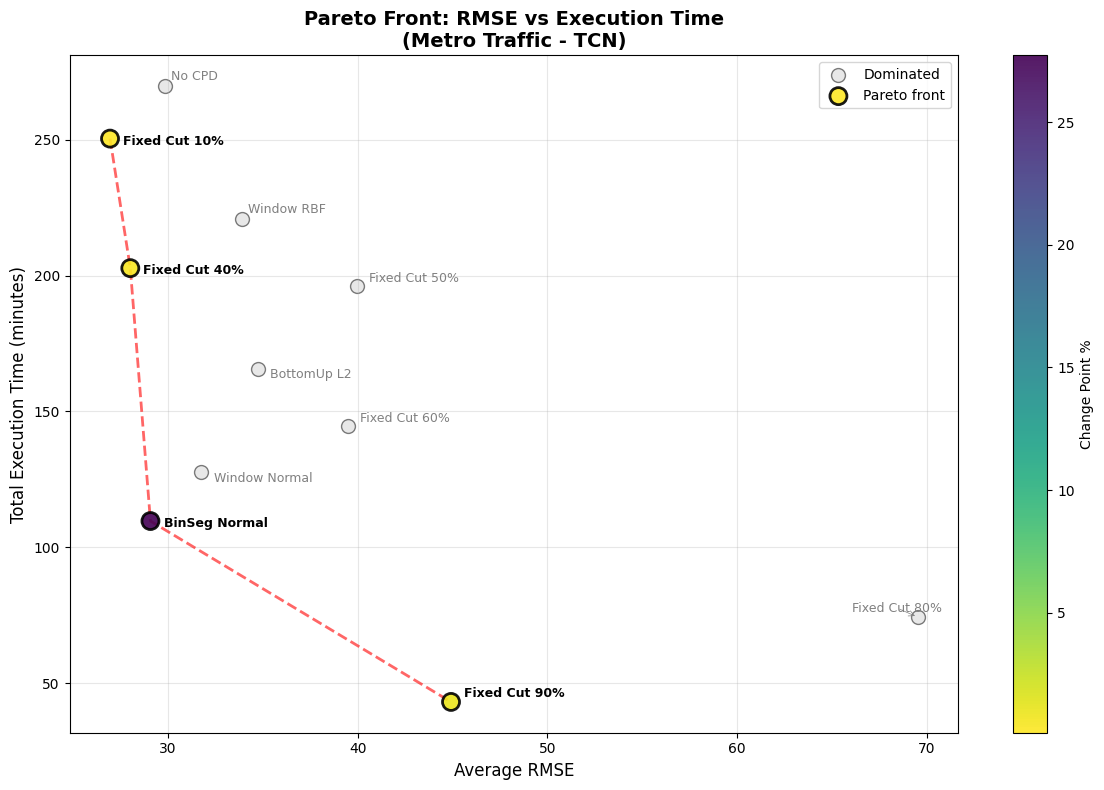


Pareto Optimal Approaches - Metro Traffic / TCN (optimizing RMSE and ET):
Fixed Cut 10%                  | RMSE: 26.9431 | ET:   250.37 min
Fixed Cut 40%                  | RMSE: 28.0121 | ET:   202.71 min
BinSeg Normal                  | RMSE: 29.0735 | ET:   109.67 min
Fixed Cut 90%                  | RMSE: 44.9163 | ET:    43.12 min


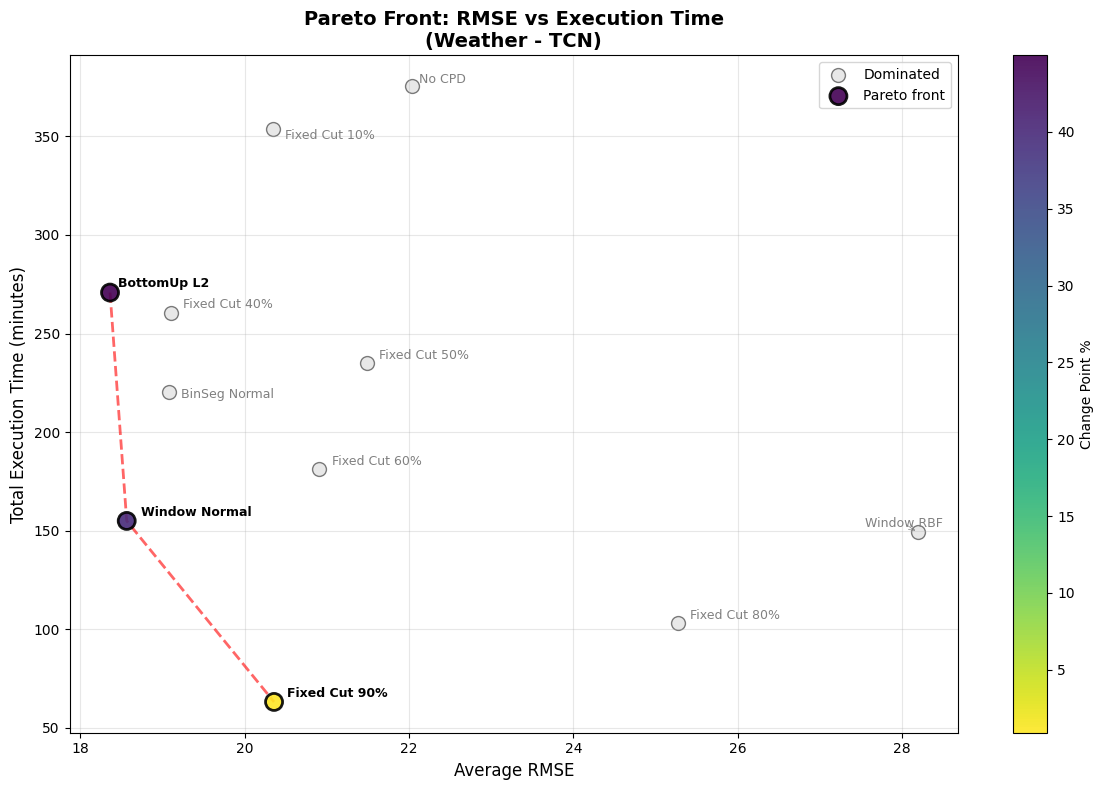


Pareto Optimal Approaches - Weather / TCN (optimizing RMSE and ET):
BottomUp L2                    | RMSE: 18.3629 | ET:   270.76 min
Window Normal                  | RMSE: 18.5660 | ET:   154.97 min
Fixed Cut 90%                  | RMSE: 20.3587 | ET:    63.19 min


In [16]:
# Pareto fronts per forecaster
for forecaster in FORECASTER_TYPES:
    print(f"\n{forecaster}:")
    for ds in DATASETS_NAMES:
        df = all_comp_dfs[forecaster][all_comp_dfs[forecaster][DATASET_NAME_COL] == ds].copy().rename(columns={
            f"{CHANGE_POINT_PERC_COL}_seed_{SEEDS[0]}": CHANGE_POINT_PERC_COL,
            f"{PRIMARY_METRIC}_mean": PRIMARY_METRIC,
            f"{ET_TOTAL_COL}_mean": ET_TOTAL_COL,
        })
        plot_pareto_front(df, f"{OUTPUT_FOLDER}/{forecaster}", PRIMARY_METRIC, 
                          filename=f"{ds}_pareto.png", dataset_name=ds, forecaster_type=forecaster)

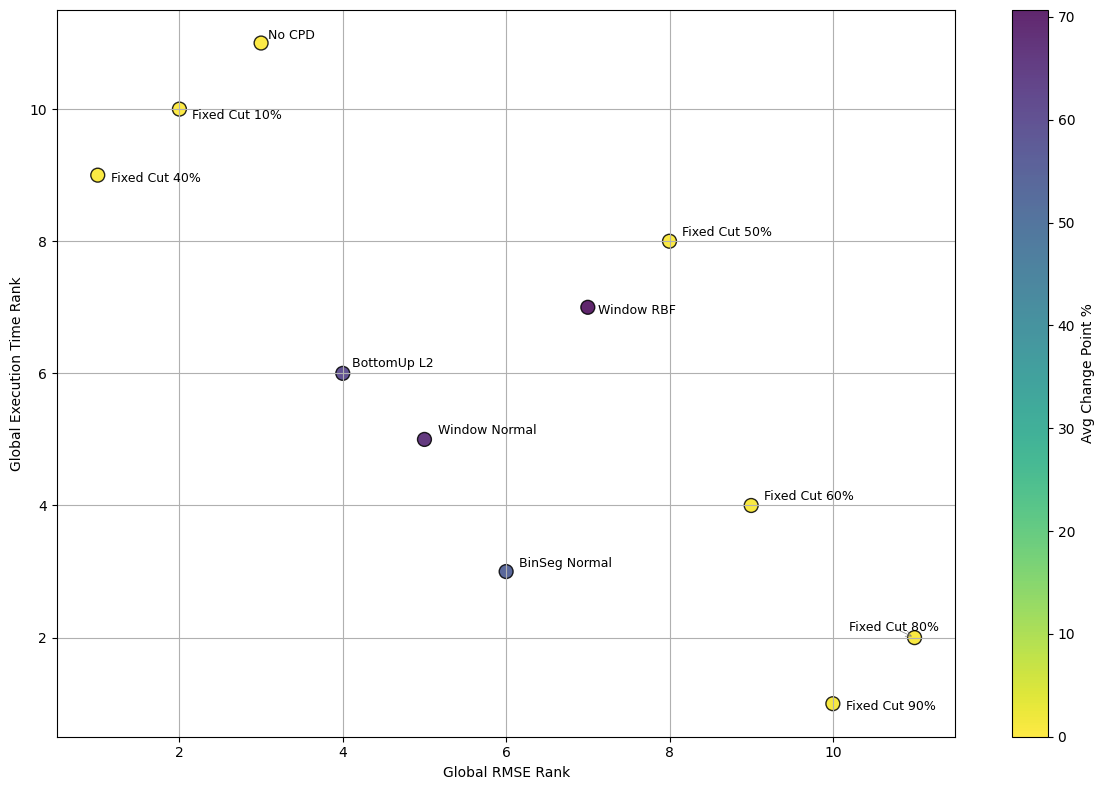

,change_point_approach,Avg_RMSE_mean,ET_Total_mean,change_point_perc_seed_42,metric_rank,et_rank
0,BinSeg Normal,21.447733,65.047100,54.369483,6.0,3.0
1,BottomUp L2,20.898908,83.475825,59.964233,4.0,6.0
2,Fixed Cut 10%,20.751517,139.657800,0.100000,2.0,10.0
3,Fixed Cut 40%,20.663442,101.946717,0.400000,1.0,9.0
4,Fixed Cut 50%,21.628917,88.977367,0.500000,8.0,8.0
5,Fixed Cut 60%,21.890500,71.632908,0.600000,9.0,4.0
6,Fixed Cut 80%,25.336500,42.734250,0.800000,11.0,2.0
7,Fixed Cut 90%,23.485425,26.030100,0.900000,10.0,1.0
8,No CPD,20.839475,149.651967,0.000000,3.0,11.0
9,Window Normal,21.012883,78.814358,66.283283,5.0,5.0


In [17]:
# Combined aggregated scatter
plot_aggregated_scatter(combined_df, OUTPUT_FOLDER, PRIMARY_METRIC, "aggregated_scatter_combined.png")